In [4]:
!pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longe

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка датасета из файла
df = pd.read_csv('diamonds.csv')

# Первичный осмотр
print("Размерность:", df.shape)
print("\nТипы данных:")
print(df.dtypes)
print("\nПропуски:\n", df.isnull().sum())
print("\nПервые 5 строк:")
df.head()

Размерность: (50000, 10)

Типы данных:
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

Пропуски:
 carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Первые 5 строк:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [6]:
# Проверка пропусков
print("Количество пропусков по столбцам:")
print(df.isnull().sum())
print("\nОбщее количество пропусков:", df.isnull().sum().sum())

Количество пропусков по столбцам:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Общее количество пропусков: 0


In [7]:
# Анализ выбросов с помощью IQR для числовых признаков
num_cols = df.select_dtypes(include=np.number).columns  # только числовые признаки

for col in num_cols:
    Q1 = df[col].quantile(0.25)   # первый квартиль
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1                  # межквартильный размах
    lower = Q1 - 1.5 * IQR         # нижняя граница
    upper = Q3 + 1.5 * IQR         # верхняя граница
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]  # считаем выбросы
    print(f"{col}: выбросов — {outliers} ({outliers/df.shape[0]*100:.1f}%)")

carat: выбросов — 1770 (3.5%)
depth: выбросов — 2359 (4.7%)
table: выбросов — 558 (1.1%)
price: выбросов — 3264 (6.5%)
x: выбросов — 31 (0.1%)
y: выбросов — 28 (0.1%)
z: выбросов — 45 (0.1%)


In [8]:
# Проверяем типы перед преобразованием
print("Типы данных до преобразования:")
print(df.dtypes)

#Преобразуем категориальные колонки в тип category
cat_cols = ['cut', 'color', 'clarity']
for col in cat_cols:
    df[col] = df[col].astype('category')

print("\nТипы данных после преобразования:")
print(df.dtypes)

Типы данных до преобразования:
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

Типы данных после преобразования:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object


In [9]:
# Описательные статистики числовых признаков
print("Описательные статистики числовых признаков:")
df.describe()

Описательные статистики числовых признаков:


,carat,depth,table,price,x,y,z
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.799444,61.753006,57.457830,3944.805440,5.734403,5.737956,3.541056
std,0.475173,1.431088,2.232092,3997.938105,1.123077,1.145579,0.707065
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2410.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5351.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [10]:
# Описательные статистики категориальных признаков
print("Распределение категориальных признаков:")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

Распределение категориальных признаков:

cut:
cut
Ideal        19938
Premium      12806
Very Good    11204
Good          4557
Fair          1495
Name: count, dtype: int64

color:
color
G    10452
E     9085
F     8864
H     7711
D     6224
I     5058
J     2606
Name: count, dtype: int64

clarity:
clarity
SI1     12115
VS2     11404
SI2      8519
VS1      7579
VVS2     4694
VVS1     3369
IF       1632
I1        688
Name: count, dtype: int64


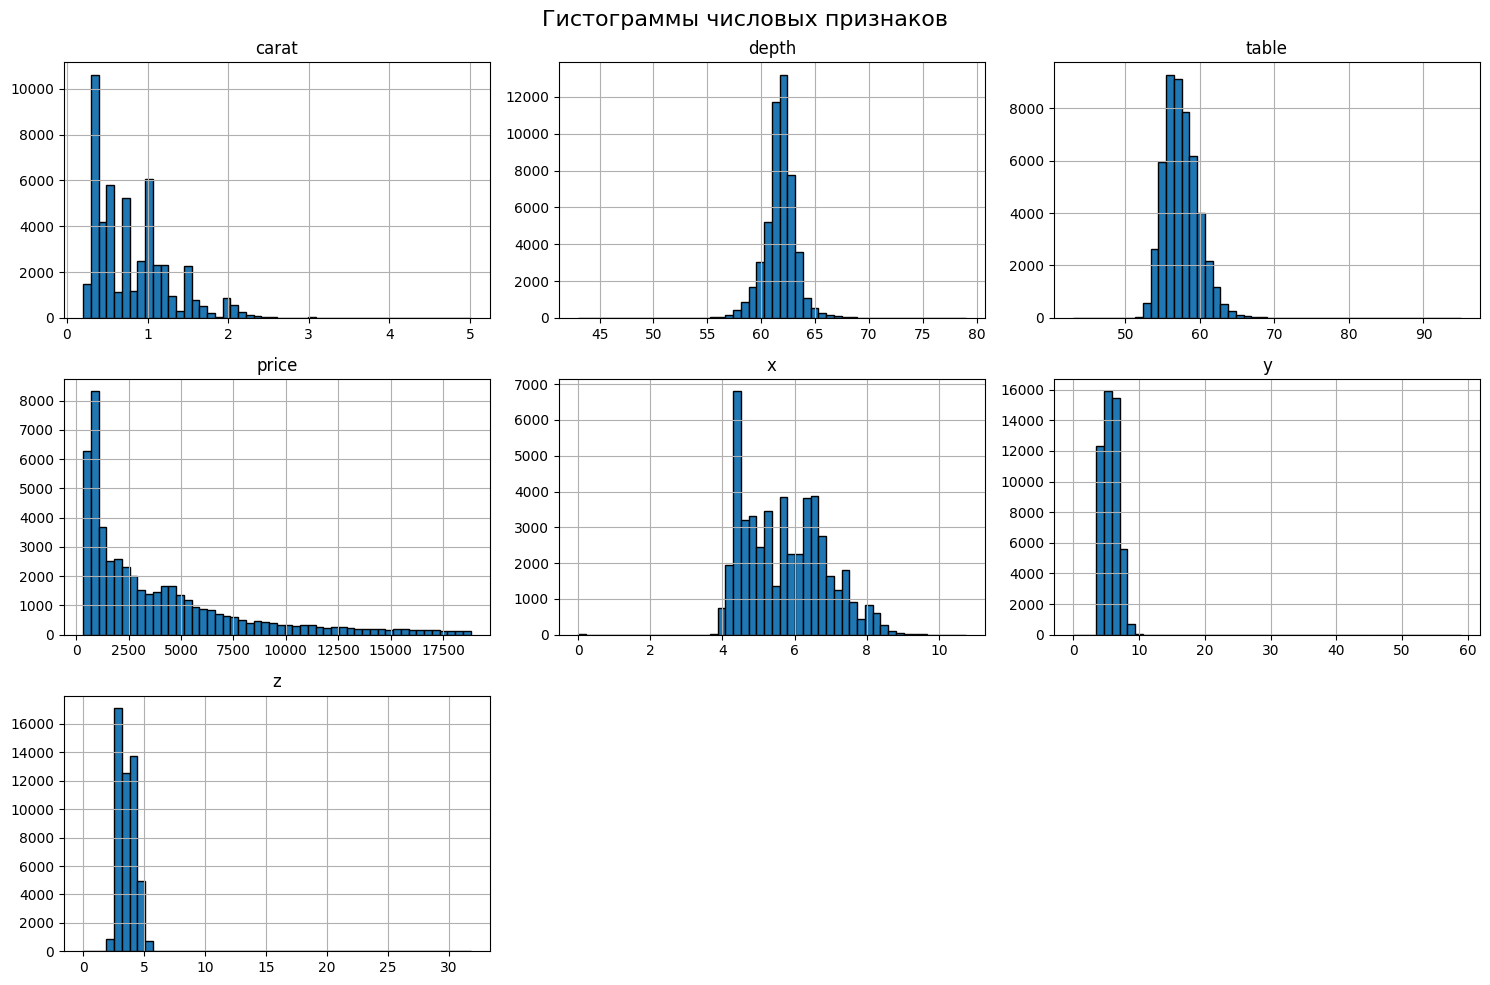

In [11]:
# Гистограммы числовых признаков
df.hist(bins=50, figsize=(15, 10), edgecolor='black')
plt.suptitle('Гистограммы числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

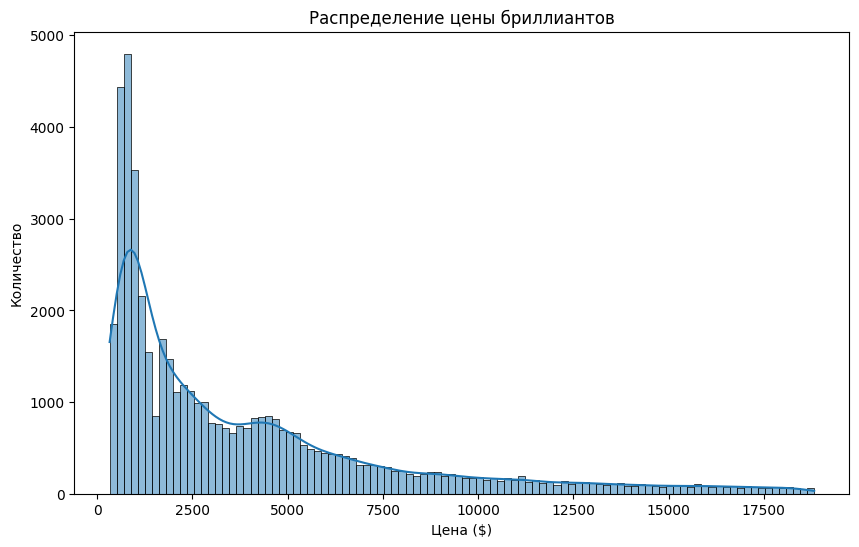

In [12]:
# Распределение целевой переменной price
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=100, kde=True, edgecolor='black')
plt.title('Распределение цены бриллиантов')
plt.xlabel('Цена ($)')
plt.ylabel('Количество')
plt.show()

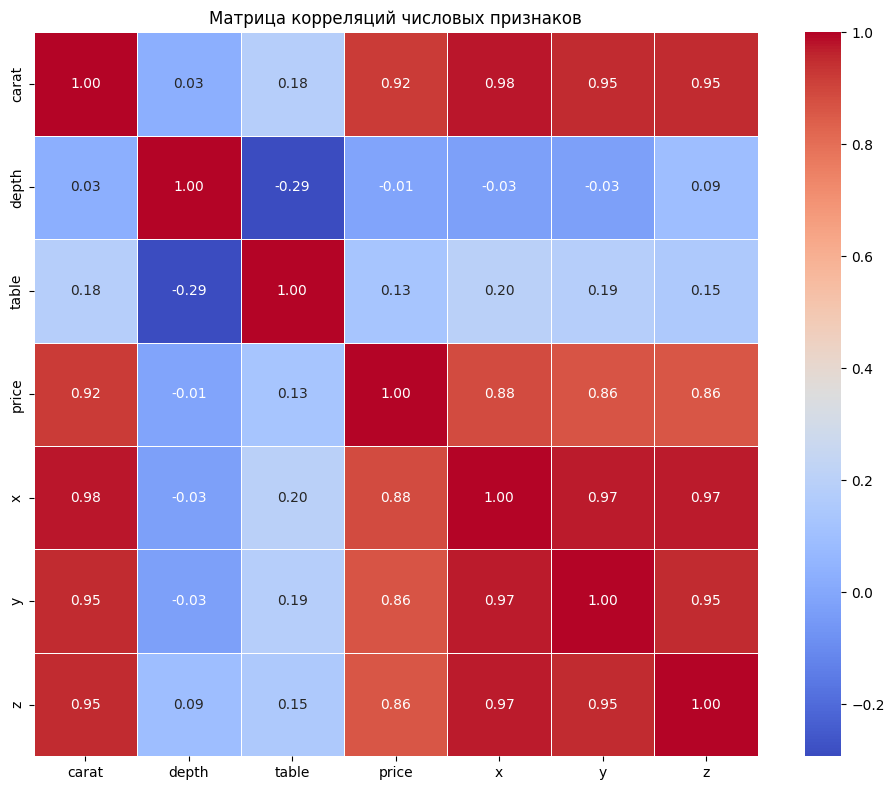

In [13]:
# Матрица корреляций
num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True)
plt.title('Матрица корреляций числовых признаков')
plt.tight_layout()
plt.show()

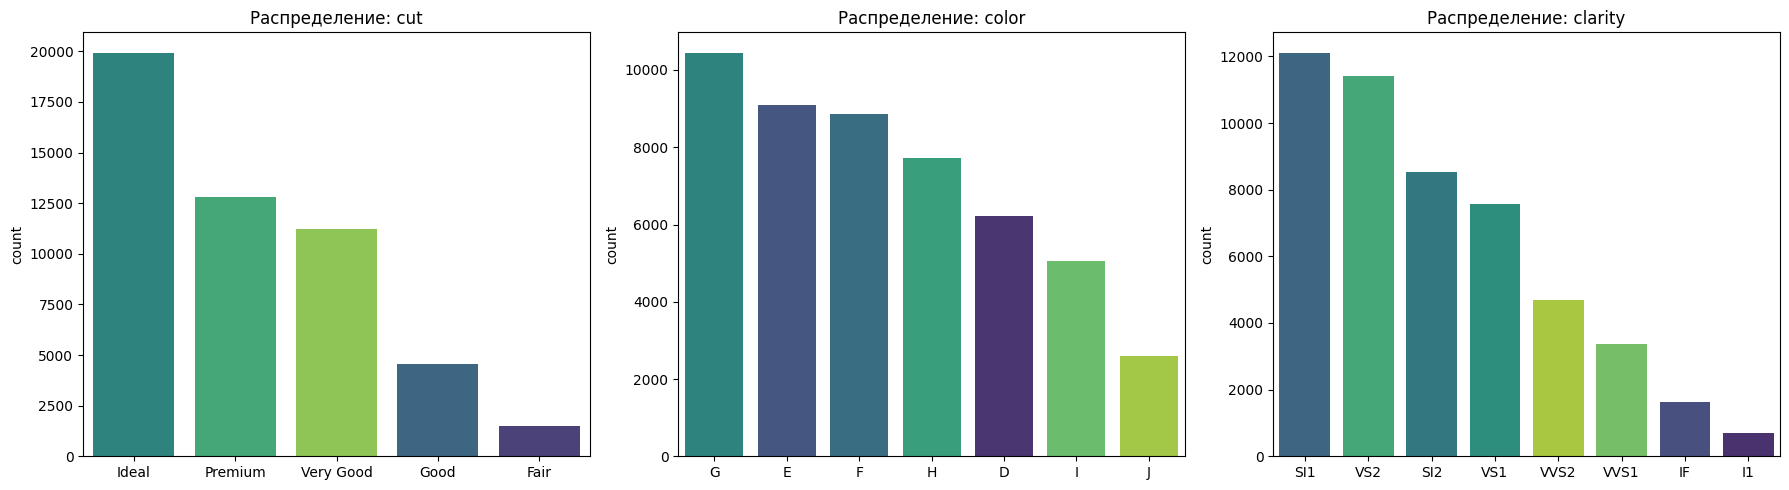

In [14]:
# Count plots для категориальных переменных
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # создаём строку из трёх графиков
for ax, col in zip(axes, cat_cols):  # проходим по каждому категориальному признаку
    sns.countplot(data=df, x=col, ax=ax, order=df[col].value_counts().index,
                  hue=col, palette='viridis', legend=False)  # строим столбцы по частоте
    ax.set_title(f'Распределение: {col}')  # заголовок графика
    ax.set_xlabel('')  # убираем подпись оси X, так как название признака уже в заголовке
plt.tight_layout()  # автоматически настраиваем отступы, чтобы подписи не наезжали
plt.show()  # выводим графики на экран

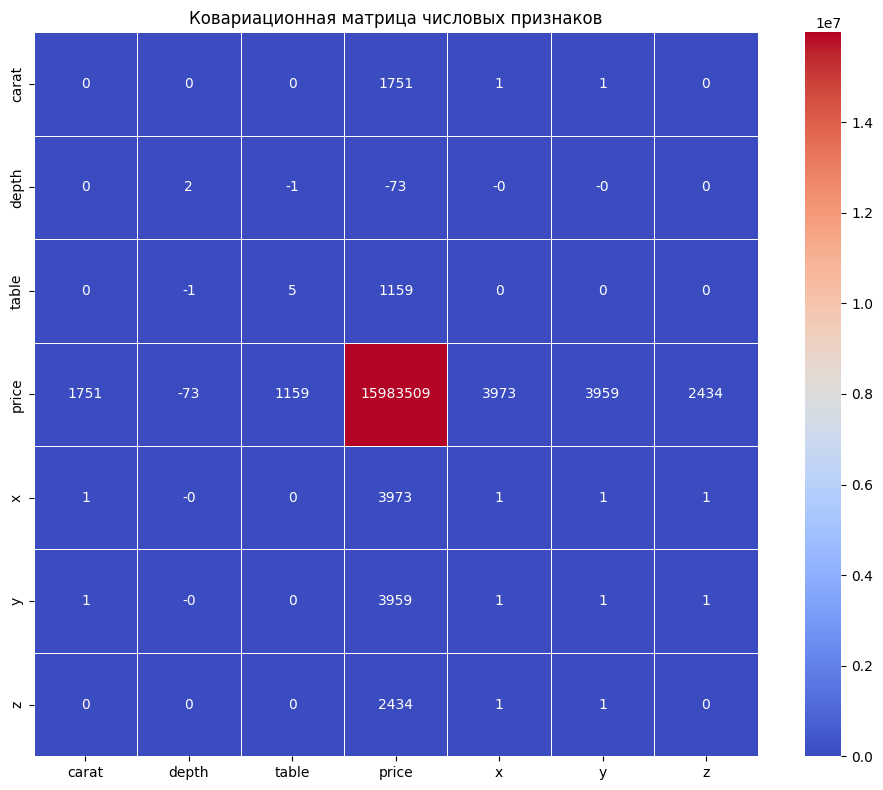

Ковариационная матрица:


,carat,depth,table,price,x,y,z
carat,0.225789,0.018860,0.194773,1.751162e+03,0.520335,0.517150,0.320086
depth,0.018860,2.048012,-0.935974,-7.283680e+01,-0.041085,-0.048869,0.095457
table,0.194773,-0.935974,4.982234,1.158731e+03,0.494339,0.473686,0.241723
price,1751.161797,-72.836802,1158.730886,1.598351e+07,3973.282382,3958.879459,2433.770357
x,0.520335,-0.041085,0.494339,3.973282e+03,1.261303,1.251807,0.770363
y,0.517150,-0.048869,0.473686,3.958879e+03,1.251807,1.312352,0.769523
z,0.320086,0.095457,0.241723,2.433770e+03,0.770363,0.769523,0.499941


In [15]:
# Запрос к ИИ: «Сгенерируй код на Python для вычисления ковариационной матрицы
# числовых признаков датасета diamonds.csv и её визуализации в виде тепловой карты»

num_cols = df.select_dtypes(include=np.number).columns  # отбираем только числовые столбцы
cov_matrix = df[num_cols].cov()  # вычисляем ковариационную матрицу

plt.figure(figsize=(10, 8))  # задаём размер тепловой карты
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', fmt='.0f',
            linewidths=0.5, square=True)  # строим тепловую карту с числовыми подписями
plt.title('Ковариационная матрица числовых признаков')
plt.tight_layout()
plt.show()

print("Ковариационная матрица:")
cov_matrix  # выводим числовые значения в табличном виде

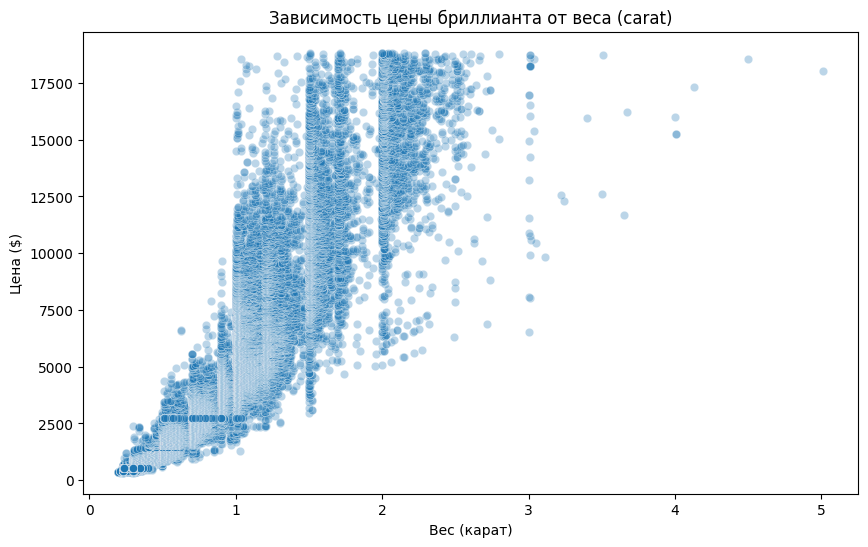

In [16]:
# Зависимость цены бриллианта от веса
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='carat', y='price', alpha=0.3)
plt.title('Зависимость цены бриллианта от веса (carat)')
plt.xlabel('Вес (карат)')
plt.ylabel('Цена ($)')
plt.show()

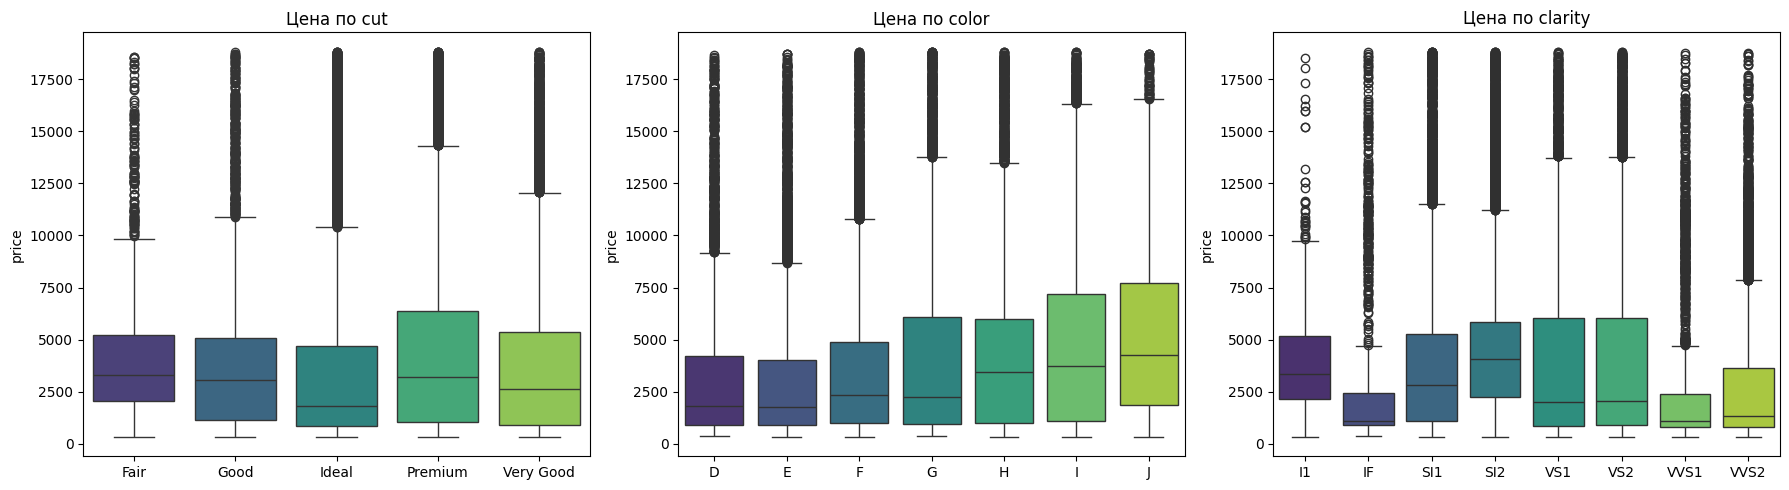

In [17]:
# Boxplot цены по категориям cut, color, clarity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # создаём строку из трёх графиков

for ax, col in zip(axes, cat_cols):
    sns.boxplot(data=df, x=col, y='price', ax=ax,
                order=sorted(df[col].unique()),  # сортируем категории по алфавиту
                hue=col, palette='viridis', legend=False)
    ax.set_title(f'Цена по {col}')  # заголовок с названием признака
    ax.set_xlabel('')  # убираем подпись оси X для компактности

plt.tight_layout()
plt.show()

In [18]:
# средняя цена по категориям
for col in cat_cols:
    print(f"\nСредняя цена по {col}:")
    print(df.groupby(col, observed=True)['price'].mean().sort_values(ascending=False))


Средняя цена по cut:
cut
Premium      4607.382867
Fair         4329.705017
Very Good    3986.585594
Good         3961.470266
Ideal        3463.090230
Name: price, dtype: float64

Средняя цена по color:
color
J    5343.118189
I    5105.049822
H    4497.667877
G    4004.079219
F    3740.307198
D    3178.897333
E    3084.542763
Name: price, dtype: float64

Средняя цена по clarity:
clarity
SI2     5093.672379
SI1     3999.743211
I1      3940.620640
VS2     3937.024027
VS1     3839.020715
VVS2    3276.512356
IF      2902.974265
VVS1    2543.151677
Name: price, dtype: float64


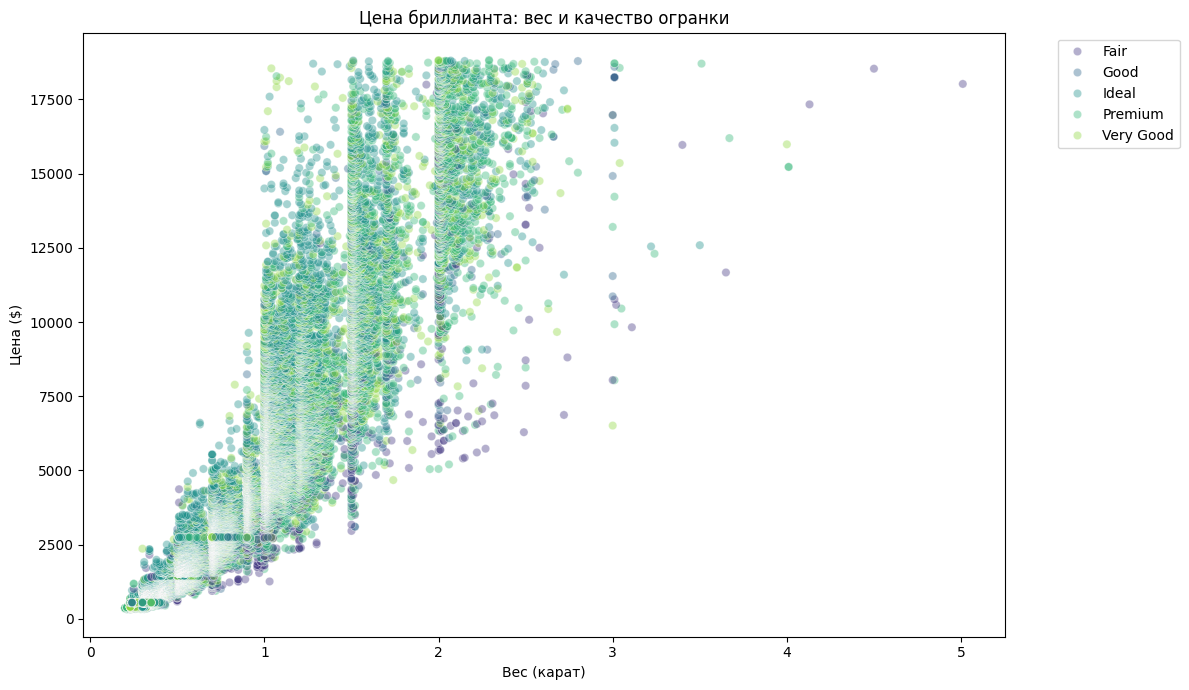

In [19]:
# Совместное влияние carat и cut на цену
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='carat', y='price', hue='cut',
                alpha=0.4, palette='viridis')
plt.title('Цена бриллианта: вес и качество огранки')
plt.xlabel('Вес (карат)')
plt.ylabel('Цена ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

# Разделение на обучающую и тестовую выборки 80/20
# random_state=42 фиксирует случайное зерно для воспроизводимости результатов
# При повторном запуске разбиение будет точно таким же
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {train_data.shape}")
print(f"Тестовая выборка: {test_data.shape}")

Обучающая выборка: (40000, 10)
Тестовая выборка: (10000, 10)


In [26]:
# # Если нужно обучить модель заново — раскомментируйте строки ниже
# from autogluon.tabular import TabularDataset, TabularPredictor
#
# label = 'price'
#
# predictor = TabularPredictor(
#     label=label,
#     eval_metric='root_mean_squared_error'
# ).fit(
#     train_data,
#     time_limit=7200,
#     presets='medium_quality'
# )

# Если нужно загрузить готовую модель — выполните код ниже
label = 'price'

from autogluon.tabular import TabularPredictor

# Распаковываем архив в корневую папку /content/
!unzip -o autogluon_model.zip -d /

# Загружаем модель
predictor = TabularPredictor.load("/content/AutogluonModels/ag-20260515_113621")
print("Модель загружена.")

Archive:  autogluon_model.zip
  inflating: /content/AutogluonModels/ag-20260515_113621/learner.pkl  
 extracting: /content/AutogluonModels/ag-20260515_113621/version.txt  
  inflating: /content/AutogluonModels/ag-20260515_113621/utils/attr/NeuralNetTorch/y_pred_proba_val.pkl  
  inflating: /content/AutogluonModels/ag-20260515_113621/utils/attr/RandomForestMSE/y_pred_proba_val.pkl  
  inflating: /content/AutogluonModels/ag-20260515_113621/utils/attr/ExtraTreesMSE/y_pred_proba_val.pkl  
  inflating: /content/AutogluonModels/ag-20260515_113621/utils/attr/LightGBMLarge/y_pred_proba_val.pkl  
  inflating: /content/AutogluonModels/ag-20260515_113621/utils/attr/XGBoost/y_pred_proba_val.pkl  
  inflating: /content/AutogluonModels/ag-20260515_113621/utils/attr/LightGBMXT/y_pred_proba_val.pkl  
  inflating: /content/AutogluonModels/ag-20260515_113621/utils/attr/NeuralNetFastAI/y_pred_proba_val.pkl  
  inflating: /content/AutogluonModels/ag-20260515_113621/utils/attr/LightGBM/y_pred_proba_val.pkl

In [27]:
# Лидерборд
leaderboard = predictor.leaderboard(train_data, silent=True)
print("Лидерборд моделей (топ-10):")
print(leaderboard.head(10))

# Лучшая модель
best_model = predictor.model_best
print(f"\nЛучшая модель: {best_model}")

Лидерборд моделей (топ-10):
                 model  score_test   score_val              eval_metric  \
0        ExtraTreesMSE -237.306842 -527.519109  root_mean_squared_error   
1      RandomForestMSE -243.368141 -554.884871  root_mean_squared_error   
2        LightGBMLarge -369.166392 -558.874937  root_mean_squared_error   
3  WeightedEnsemble_L2 -391.811972 -499.021234  root_mean_squared_error   
4              XGBoost -398.200814 -519.583798  root_mean_squared_error   
5             CatBoost -423.236769 -512.799573  root_mean_squared_error   
6           LightGBMXT -425.604007 -518.779638  root_mean_squared_error   
7             LightGBM -462.964152 -522.666860  root_mean_squared_error   
8      NeuralNetFastAI -548.572645 -535.294811  root_mean_squared_error   
9       NeuralNetTorch -636.988208 -596.016169  root_mean_squared_error   

   pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  \
0        3.221724       0.418486   23.244831                 3.221724   


In [30]:
from sklearn.metrics import mean_squared_error, r2_score

y_test = test_data[label]
y_pred = predictor.predict(test_data.drop(columns=[label]))

# Вычисляем метрики
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"AutoML (лучшая модель) на тестовой выборке:")
print(f"RMSE: {rmse:.2f} долларов")
print(f"R²: {r2:.4f}")

AutoML (лучшая модель) на тестовой выборке:
RMSE: 492.72 долларов
R²: 0.9843


In [31]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Построение базовой модели — линейной регрессии
# Числовые признаки стандартизируются (среднее=0, стд=1), категориальные кодируются OneHot
X_train = train_data.drop(columns=[label])
y_train_lr = train_data[label]
X_test = test_data.drop(columns=[label])

# Разделяем колонки по типам
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Предобработка: StandardScaler для числовых, OneHotEncoder для категориальных
# drop='first' удаляет первую категорию, чтобы избежать мультиколлинеарности
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

# Пайплайн: сначала предобработка, затем линейная регрессия
baseline_pipe = Pipeline([
    ('prep', preprocessor),
    ('lr', LinearRegression())
])

# Обучение и прогноз
baseline_pipe.fit(X_train, y_train_lr)
y_pred_lr = baseline_pipe.predict(X_test)

# Метрики качества базовой модели
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Базовая модель (Linear Regression):")
print(f"RMSE: {rmse_lr:.2f} долларов")
print(f"R²: {r2_lr:.4f}")

Базовая модель (Linear Regression):
RMSE: 1089.38 долларов
R²: 0.9232


In [32]:
#Сохранение модели
!zip -r autogluon_model.zip /content/AutogluonModels/ag-20260515_113621
from google.colab import files
files.download("autogluon_model.zip")

updating: content/AutogluonModels/ag-20260515_113621/ (stored 0%)
updating: content/AutogluonModels/ag-20260515_113621/learner.pkl (deflated 66%)
updating: content/AutogluonModels/ag-20260515_113621/version.txt (stored 0%)
updating: content/AutogluonModels/ag-20260515_113621/utils/ (stored 0%)
updating: content/AutogluonModels/ag-20260515_113621/utils/attr/ (stored 0%)
updating: content/AutogluonModels/ag-20260515_113621/utils/attr/NeuralNetTorch/ (stored 0%)
updating: content/AutogluonModels/ag-20260515_113621/utils/attr/NeuralNetTorch/y_pred_proba_val.pkl (deflated 10%)
updating: content/AutogluonModels/ag-20260515_113621/utils/attr/RandomForestMSE/ (stored 0%)
updating: content/AutogluonModels/ag-20260515_113621/utils/attr/RandomForestMSE/y_pred_proba_val.pkl (deflated 10%)
updating: content/AutogluonModels/ag-20260515_113621/utils/attr/ExtraTreesMSE/ (stored 0%)
updating: content/AutogluonModels/ag-20260515_113621/utils/attr/ExtraTreesMSE/y_pred_proba_val.pkl (deflated 10%)
updatin

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Этап 4

In [33]:
# Установка SHAP
!pip install shap -q

import shap
import lightgbm as lgb

In [34]:
# Копируем данные
X_train_lgb = train_data.drop(columns=['price']).copy()
y_train_lgb = train_data['price']
X_test_lgb = test_data.drop(columns=['price']).copy()

# Определяем категориальные колонки
cat_cols = X_train_lgb.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Категориальные признаки: {cat_cols}")

# Преобразуем в тип category
for c in cat_cols:
    X_train_lgb[c] = X_train_lgb[c].astype('category')
    X_test_lgb[c] = X_test_lgb[c].astype('category')

Категориальные признаки: ['cut', 'color', 'clarity']


In [35]:
# Обучение LightGBM — одной из моделей, входящих в ансамбль AutoML
# LightGBM эффективно работает с категориальными признаками без ручного кодирования
model_lgb = lgb.LGBMRegressor(
    random_state=42,     # фиксируем случайное зерно для воспроизводимости
    n_estimators=500,    # количество деревьев в ансамбле
    verbose=-1           # отключаем вывод служебных сообщений
)
model_lgb.fit(X_train_lgb, y_train_lgb, categorical_feature=cat_cols)

# Оценка качества LightGBM на тестовой выборке
from sklearn.metrics import mean_squared_error, r2_score

y_pred_lgb = model_lgb.predict(X_test_lgb)
rmse_lgb = np.sqrt(mean_squared_error(test_data['price'], y_pred_lgb))
r2_lgb = r2_score(test_data['price'], y_pred_lgb)

print(f"LightGBM Тест RMSE: {rmse_lgb:.2f}")  # средняя ошибка в долларах
print(f"LightGBM Тест R²: {r2_lgb:.4f}")       # доля объяснённой дисперсии

LightGBM Тест RMSE: 518.17
LightGBM Тест R²: 0.9826


In [36]:
# Создаём TreeExplainer для LightGBM
explainer = shap.TreeExplainer(model_lgb)

# Берём подвыборку из тестовых данных для вычисления SHAP значений
X_sample = X_test_lgb.sample(n=1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

print(f"Форма SHAP значений: {shap_values.shape}")

Форма SHAP значений: (1000, 9)


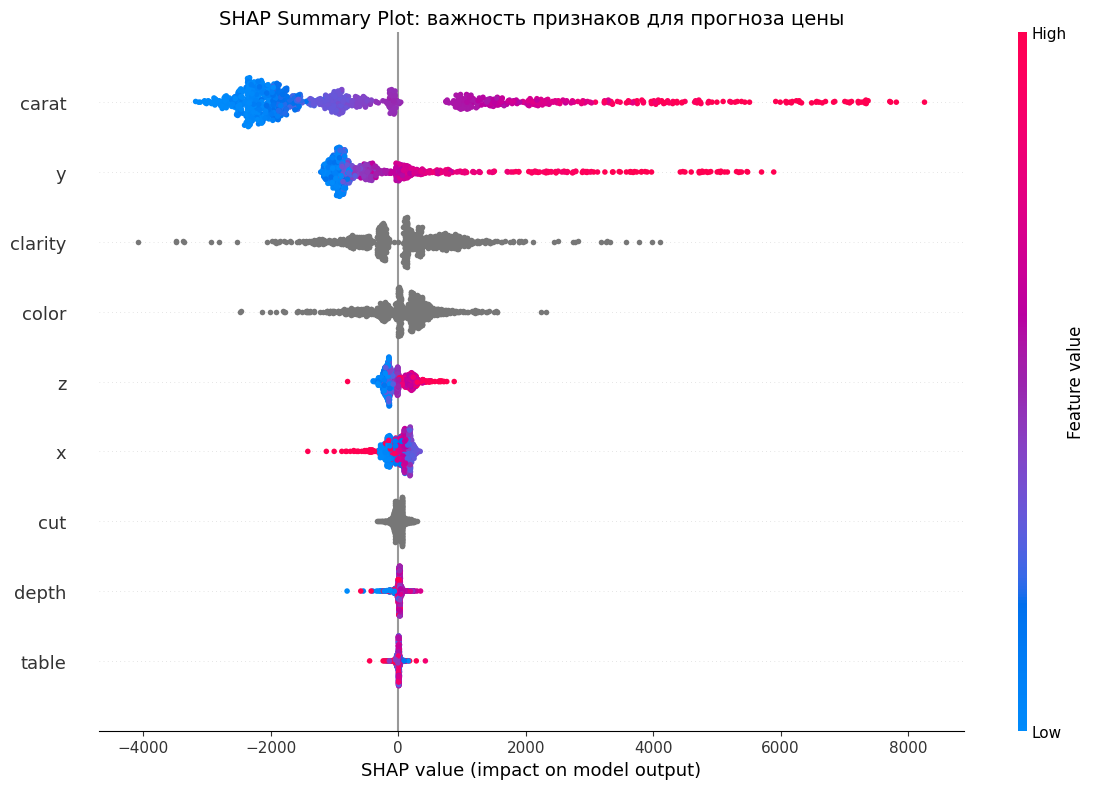

In [37]:
# Summary plot
shap.summary_plot(shap_values, X_sample, plot_size=(12, 8), show=False)
plt.title('SHAP Summary Plot: важность признаков для прогноза цены', fontsize=14)
plt.tight_layout()
plt.show()

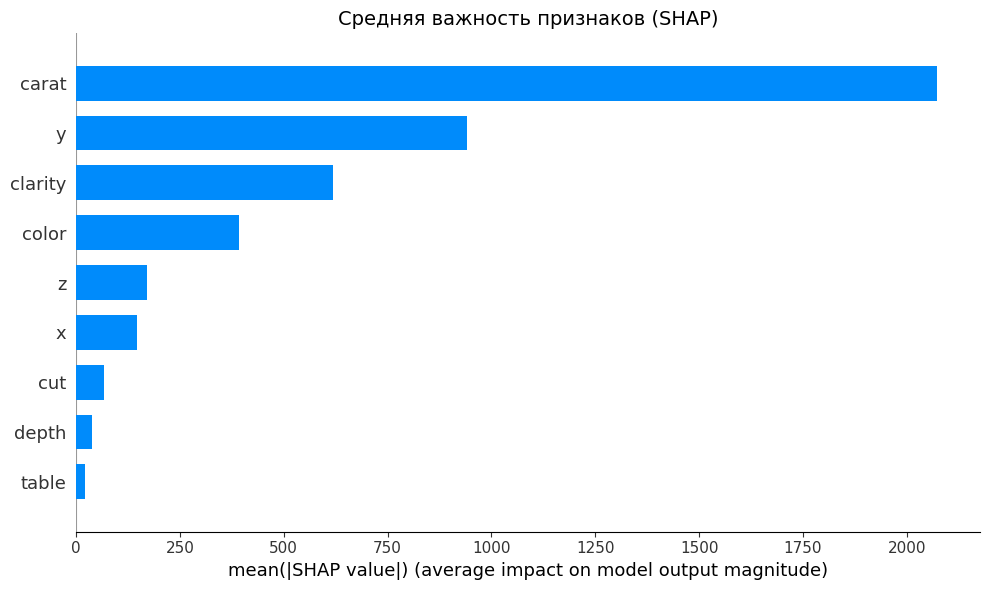

In [38]:
# Bar plot средней важности
shap.summary_plot(shap_values, X_sample, plot_type="bar", plot_size=(10, 6), show=False)
plt.title('Средняя важность признаков (SHAP)', fontsize=14)
plt.tight_layout()
plt.show()

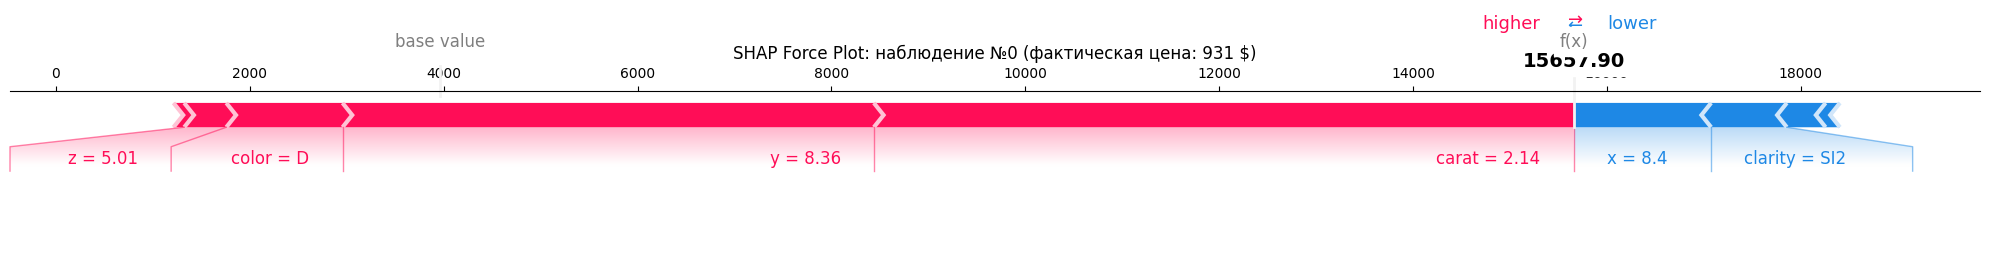

Наблюдение №0:
carat         2.14
cut        Premium
color            D
clarity        SI2
depth         59.8
table         59.0
x              8.4
y             8.36
z             5.01
Name: 25056, dtype: object
Фактическая цена: 931 $
Базовая цена (средняя): 3958 $
Предсказанная цена: 15658 $


In [39]:
# Локальное объяснение для первого примера из выборки
shap.initjs()

# Выбираем одно наблюдение
i = 0  # можно поменять на любое число от 0 до 999
shap.force_plot(
    explainer.expected_value,
    shap_values[i, :],
    X_sample.iloc[i, :],
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot: наблюдение №{i} (фактическая цена: {test_data["price"].iloc[i]:.0f} $)', fontsize=12)
plt.tight_layout()
plt.show()

# Выведем информацию о наблюдении
print(f"Наблюдение №{i}:")
print(X_sample.iloc[i])
print(f"Фактическая цена: {test_data['price'].iloc[i]:.0f} $")
print(f"Базовая цена (средняя): {explainer.expected_value:.0f} $")
print(f"Предсказанная цена: {explainer.expected_value + shap_values[i,:].sum():.0f} $")

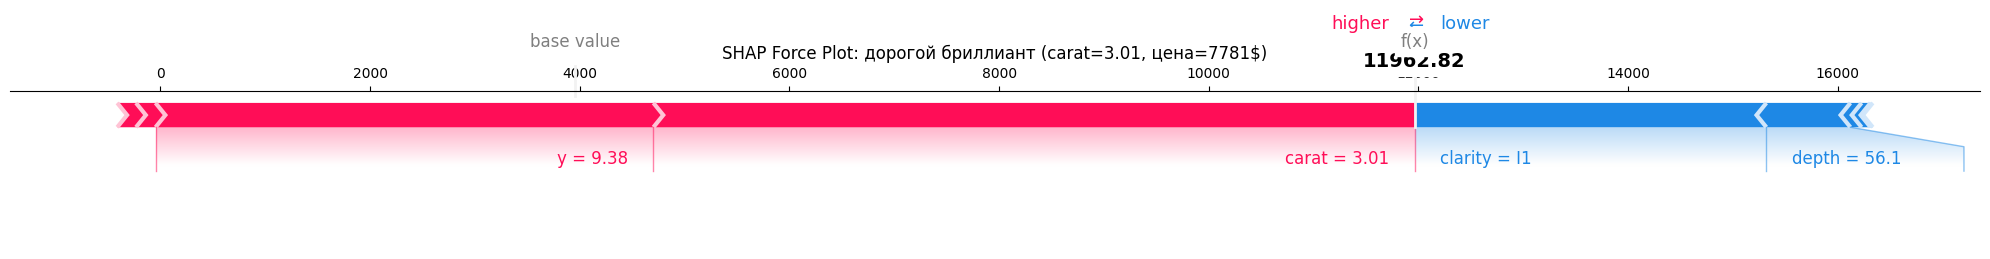

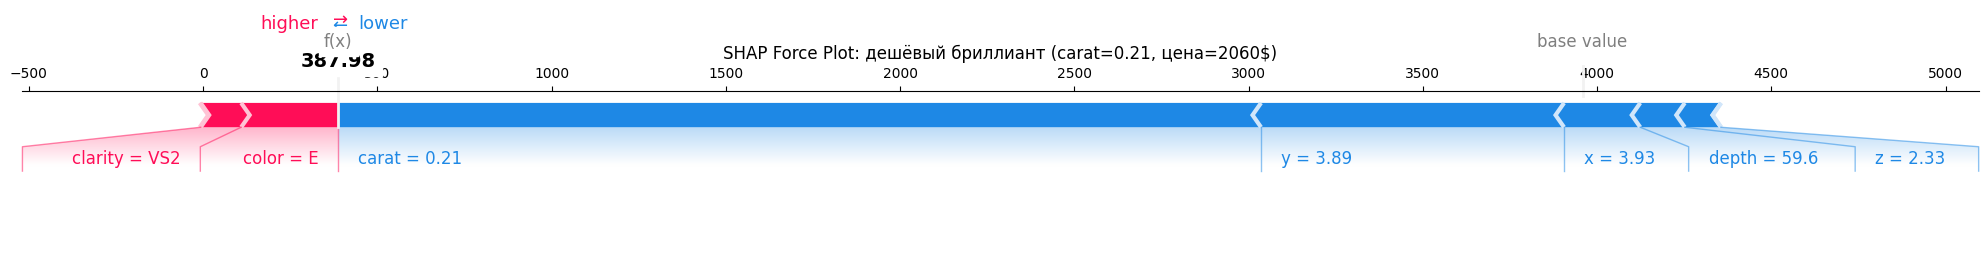

In [40]:
# Пример: найдём дорогой и дешёвый бриллианты в выборке
expensive_idx = X_sample['carat'].idxmax()  # максимальный вес в каратах
cheap_idx = X_sample['carat'].idxmin()      # минимальный вес в каратах

for idx, label in [(expensive_idx, "дорогой"), (cheap_idx, "дешёвый")]:
    i = X_sample.index.get_loc(idx)  # порядковый номер в подвыборке
    shap.force_plot(
        explainer.expected_value,     # базовая (средняя) цена по всем бриллиантам
        shap_values[i, :],            # вклад каждого признака для данного наблюдения
        X_sample.iloc[i, :],          # значения признаков
        matplotlib=True,
        show=False
    )
    plt.title(f'SHAP Force Plot: {label} бриллиант (carat={X_sample.iloc[i]["carat"]}, цена={test_data["price"].iloc[i]:.0f}$)', fontsize=12)
    plt.tight_layout()
    plt.show()

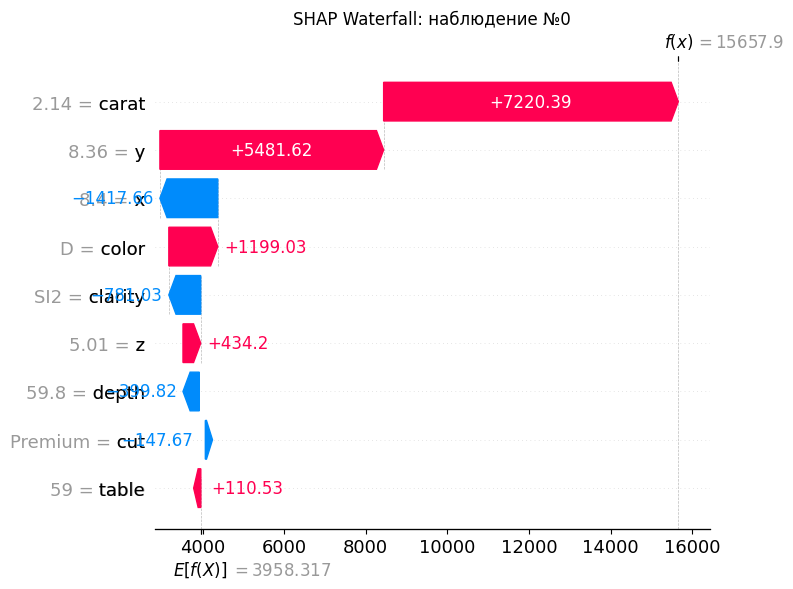

In [41]:
# Waterfall plot для одного наблюдения
i = 0
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[i, :],           # SHAP-значения для i-го наблюдения
        base_values=explainer.expected_value,  # базовая (средняя) цена
        data=X_sample.iloc[i, :].values,      # фактические значения признаков
        feature_names=X_sample.columns.tolist()  # названия признаков
    ),
    show=False
)
plt.title(f'SHAP Waterfall: наблюдение №{i}', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Создаём архив со всеми файлами проекта
!zip -r project.zip /content/diamonds.csv /content/*.ipynb /content/AutogluonModels

# Скачиваем архив
from google.colab import files
files.download('project.zip')